 # New York Airbnb Dataset
 ## Cleaning Data
 ### Description
 Data cleaning is the process of fixing or removing incorrect, corrupted, duplicate, or incomplete
 data within a dataset. Messy data leads to unreliable outcomes. Cleaning data is an essential
 part of data analysis, and demonstrating your data cleaning skills is key to landing a job. Here
 are some projects to test out your data cleaning skills:

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(r"D:\Desktop\Data_Analytics_Projects\Infobyte Internship\Airbnb\AB_NYC_2019.csv")

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

### Checking and handling missing values

In [ ]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Dropping the missing rows on columns, name and host_name

In [ ]:
df.dropna(subset=['name', 'host_name'], inplace=True)

#### Filling the blank reviews with value zero

In [ ]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

#### Assumed the last_review column

In [ ]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Checking for duplicates in the data

In [ ]:
# Checking how many duplicate rows exist
duplicate_rows = df.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())

Number of duplicate rows: 0


## Outlier Detection

In [ ]:
df[['price', 'minimum_nights', 'availability_365']].describe()

,price,minimum_nights,availability_365
count,48858.000000,48858.000000,48858.000000
mean,152.740309,7.012444,112.801425
std,240.232386,20.019757,131.610962
min,0.000000,1.000000,0.000000
25%,69.000000,1.000000,0.000000
50%,106.000000,3.000000,45.000000
75%,175.000000,5.000000,227.000000
max,10000.000000,1250.000000,365.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


## Filtering
Filtering the data to detect outliers

In [ ]:
df = df[(df['price'] <= 500) & (df['minimum_nights'] <= 30)]

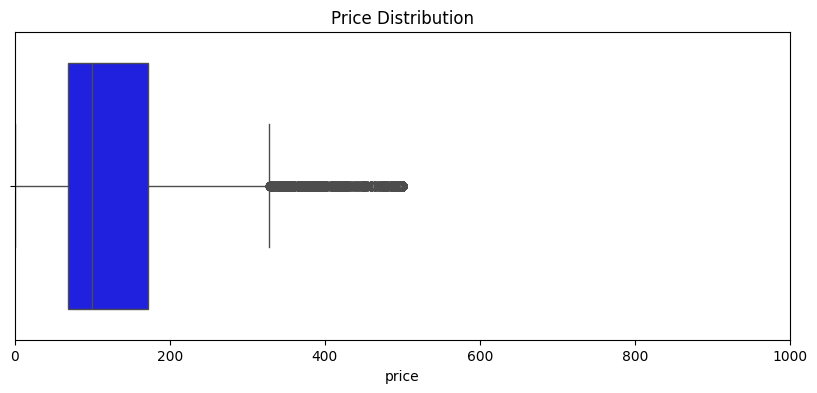

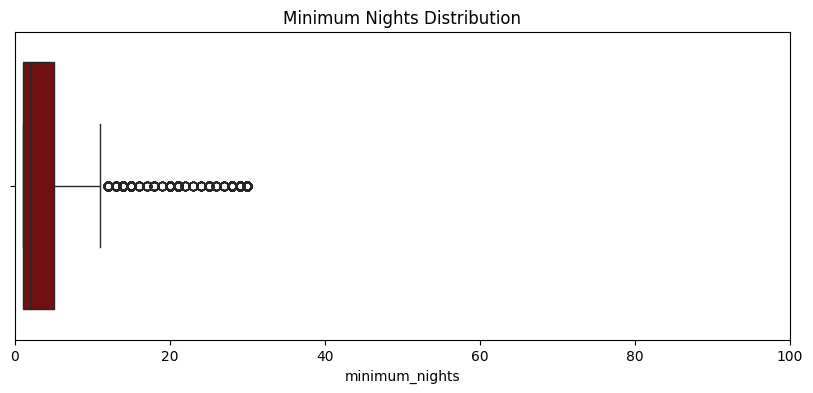

In [ ]:
# Price
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'], color='blue')
plt.title("Price Distribution")
plt.xlim(0, 1000)
plt.show()

# Minimum Nights
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['minimum_nights'], color='maroon')
plt.title("Minimum Nights Distribution")
plt.xlim(0, 100)
plt.show()

## Visualizations on the data to get insights

#### Room Type Distribution
A bar chart displaying how many listings fall into each room_type category (e.g., Entire home/apt, Private room, Shared room).

room_type
Entire home/apt    24016
Private room       21950
Shared room         1134
Name: count, dtype: int64


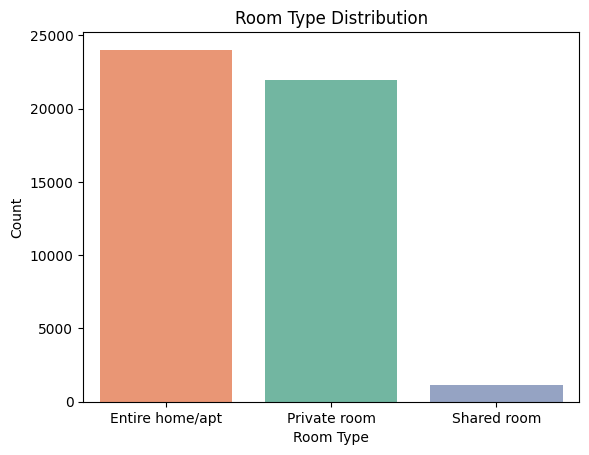

In [ ]:
room_counts = df['room_type'].value_counts()
print(room_counts)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='room_type', order=room_counts.index, hue='room_type', palette='Set2')
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()


#### Top 10 Neighbourhoods by Listings
A horizontal bar chart of the top 10 neighborhoods with the most listings.

neighbourhood
Williamsburg          3815
Bedford-Stuyvesant    3647
Harlem                2583
Bushwick              2434
Hell's Kitchen        1865
Upper West Side       1855
East Village          1789
Upper East Side       1699
Crown Heights         1532
Midtown               1362
Name: count, dtype: int64


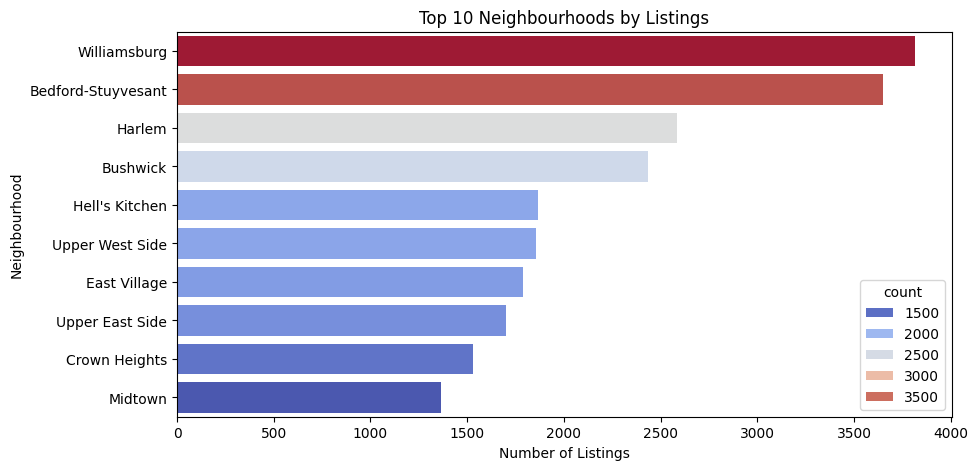

In [ ]:
top_neighbourhoods = df['neighbourhood'].value_counts().head(10)
print(top_neighbourhoods)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, hue=top_neighbourhoods, palette='coolwarm')
plt.title("Top 10 Neighbourhoods by Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.show()


#### Average Price by Room Type
A bar chart comparing the average price for each room type.

room_type
Entire home/apt    180.045969
Private room        81.846241
Shared room         63.604938
Name: price, dtype: float64


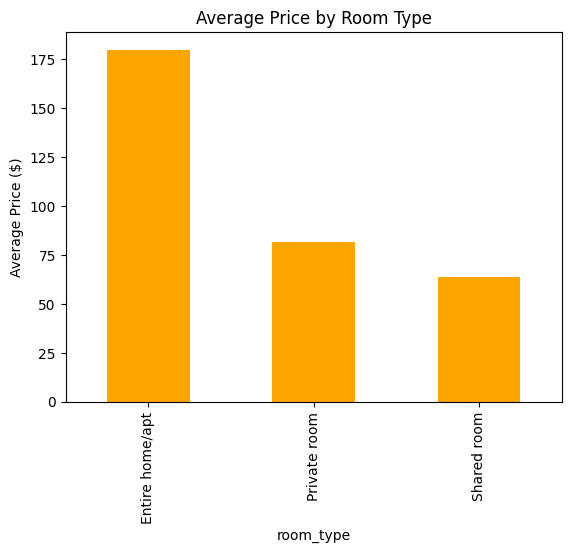

In [ ]:
avg_price_by_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_room)

# Plot
avg_price_by_room.plot(kind='bar', color='orange')
plt.title("Average Price by Room Type")
plt.ylabel("Average Price ($)")
plt.show()
